**Programming Assignment 2 CNN and data competition**

**Import tenserflow**

In [25]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt

IMG_SIZE      = (32, 32)
RESIZE_TO     = (128, 128)
BATCH_SIZE    = 128
AUTOTUNE      = tf.data.AUTOTUNE
NUM_CLASSES   = 100
WARMUP_EPOCHS = 5
TOTAL_EPOCHS  = 150

**Load and Visualize the sample (cifar 100)**

Train: 45000  |  Val: 5000  |  Test: 10000


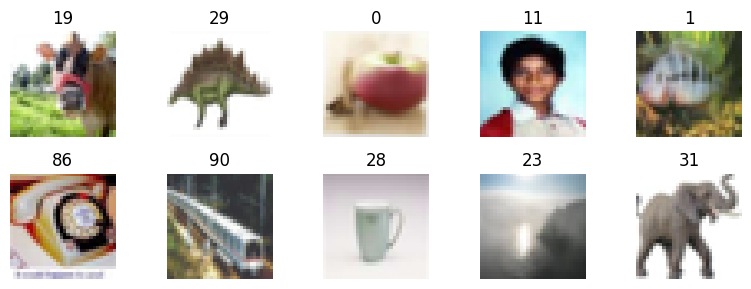

In [26]:
from sklearn.model_selection import train_test_split

(x_tr_full, y_tr_full), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()

# carve out 10 % validation set
val_size  = int(len(x_tr_full) * 0.1)
x_val,  y_val  = x_tr_full[:val_size],  y_tr_full[:val_size]
x_tr,   y_tr   = x_tr_full[val_size:],  y_tr_full[val_size:]

y_tr   = y_tr.flatten()
y_val  = y_val.flatten()
y_test = y_test.flatten()

print(f"Train: {len(x_tr)}  |  Val: {len(x_val)}  |  Test: {len(x_test)}")

plt.figure(figsize=(8, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_tr_full[i])
    plt.title(int(y_tr_full[i][0]))
    plt.axis("off")
plt.tight_layout()
plt.show()

**Construct a CNN to predict the image labels (cifar 100)**

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 4, 4, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,043,652 (80.28 MB)

 Trainable params: 709,732 (2.71 MB)

 Non-trainable params: 20,333,920 (77.57 MB)


=== Phase 1: training head (backbone frozen) ===
Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 70s 77ms/step - accuracy: 0.0530 - loss: 5.1870 - val_accuracy: 0.5254 - val_loss: 2.0203
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.3240 - loss: 2.8811 - val_accuracy: 0.5980 - val_loss: 1.5573
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.3901 - loss: 2.5180 - val_accuracy: 0.6152 - val_loss: 1.4891
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.4163 - loss: 2.3502 - val_accuracy: 0.6320 - val_loss: 1.4203
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.4384 - loss: 2.2378 - val_accuracy: 0.6392 - val_loss: 1.3953
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.4568 - loss: 2.1657 - val_accuracy: 0.6456 - val_loss: 1.3683
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.4632 - loss: 2.1251 - val_accuracy: 0.6492 - val_loss: 1.3463
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 

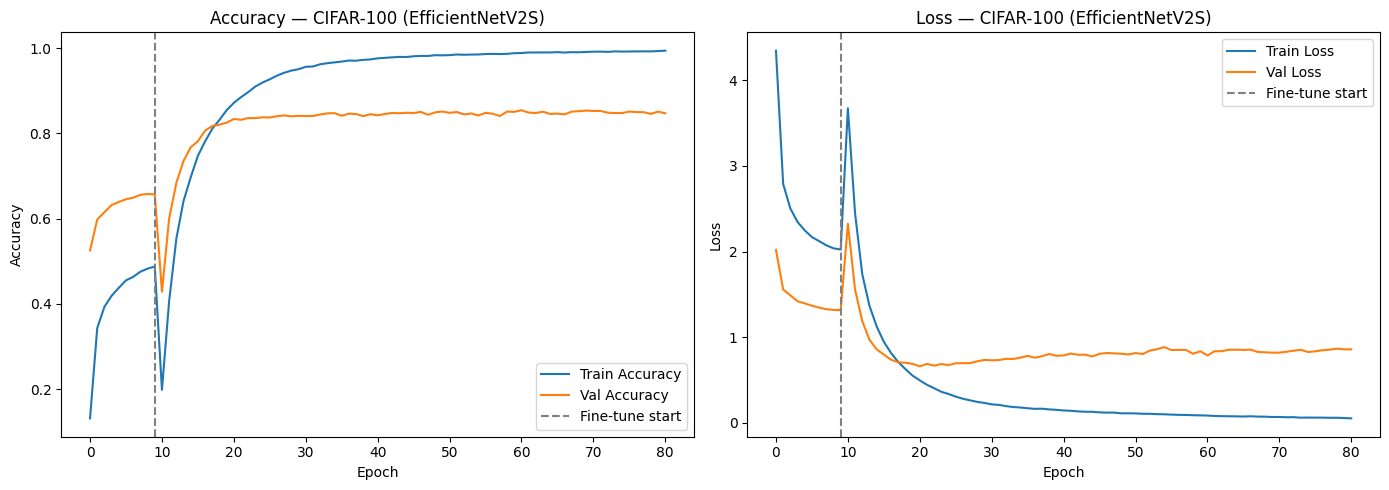


Final Test Accuracy: 0.8508 | Test Loss: 0.8110


In [27]:
def mixup(images, labels, alpha=0.2):
    """Apply MixUp augmentation to a batch."""
    batch_size = tf.shape(images)[0]
    lam = tf.cast(
        tf.random.stateless_binomial(
            shape=[], seed=(0, 0), counts=1, probs=alpha / (alpha + 1)
        ),
        tf.float32,
    )

    lam = tf.squeeze(
        tf.random.stateless_gamma([1], seed=tf.cast([batch_size, 0], tf.int64), alpha=alpha)
        / (
            tf.random.stateless_gamma([1], seed=tf.cast([batch_size, 1], tf.int64), alpha=alpha)
            + tf.random.stateless_gamma([1], seed=tf.cast([batch_size, 2], tf.int64), alpha=alpha)
            + 1e-8
        )
    )
    lam = tf.clip_by_value(lam, 0.0, 1.0)
    idx = tf.random.shuffle(tf.range(batch_size))
    mixed = lam * tf.cast(images, tf.float32) + (1.0 - lam) * tf.cast(
        tf.gather(images, idx), tf.float32
    )
    return tf.cast(mixed, images.dtype), labels, tf.gather(labels, idx), lam

data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),

], name="data_aug")

def preprocess(image, label):
    """Resize + EfficientNet preprocessing (scales to [-1, 1])."""
    image = tf.image.resize(image, RESIZE_TO)
    image = tf.keras.applications.efficientnet_v2.preprocess_input(image)
    return image, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((x_tr, y_tr))
    .shuffle(len(x_tr))
    .batch(BATCH_SIZE, drop_remainder=True)
    .map(lambda x, y: preprocess(data_aug(x, training=True), y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((x_val, y_val))
    .batch(BATCH_SIZE)
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test))
    .batch(BATCH_SIZE)
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

base = tf.keras.applications.EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=RESIZE_TO + (3,),
)
base.trainable = False  # freeze backbone initially

inputs  = layers.Input(shape=RESIZE_TO + (3,))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

steps_per_epoch = int(np.ceil(len(x_tr) / BATCH_SIZE))

class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, total_steps, warmup_steps):
        super().__init__()
        self.base_lr      = base_lr
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)
        self.cosine       = tf.keras.optimizers.schedules.CosineDecay(
            base_lr, total_steps - warmup_steps, alpha=1e-2
        )

    def __call__(self, step):
        step      = tf.cast(step, tf.float32)
        warmup_lr = self.base_lr * (step / self.warmup_steps)
        cosine_lr = self.cosine(step - self.warmup_steps)
        return tf.cond(step < self.warmup_steps, lambda: warmup_lr, lambda: cosine_lr)

    def get_config(self):
        return {"base_lr": self.base_lr, "warmup_steps": int(self.warmup_steps.numpy())}

HEAD_EPOCHS = 10
head_lr_schedule = WarmupCosineDecay(
    base_lr      = 1e-3,
    total_steps  = steps_per_epoch * HEAD_EPOCHS,
    warmup_steps = steps_per_epoch * 2,
)

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=head_lr_schedule),
    loss      = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics   = ["accuracy"],
)

print("\n=== Phase 1: training head (backbone frozen) ===")
history_phase1 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = HEAD_EPOCHS,
    verbose         = 1,
)

base.trainable = True

fine_tune_lr_schedule = WarmupCosineDecay(
    base_lr      = 1e-4,
    total_steps  = steps_per_epoch * TOTAL_EPOCHS,
    warmup_steps = steps_per_epoch * WARMUP_EPOCHS,
)

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=fine_tune_lr_schedule),
    loss      = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics   = ["accuracy"],
)

early_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=20, restore_best_weights=True, verbose=1
)

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1
)

print("\n=== Phase 2: fine-tuning full network ===")
history_phase2 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = TOTAL_EPOCHS,
    callbacks       = [early_cb, checkpoint_cb],
    verbose         = 1,
)

# ─────────────────────────────────────────────
# 8. COMBINE HISTORIES & PLOT
# ─────────────────────────────────────────────
def merge(h1, h2, key):
    return h1.history[key] + h2.history[key]

train_acc = merge(history_phase1, history_phase2, "accuracy")
val_acc   = merge(history_phase1, history_phase2, "val_accuracy")
train_loss = merge(history_phase1, history_phase2, "loss")
val_loss   = merge(history_phase1, history_phase2, "val_loss")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_acc,  label="Train Accuracy")
axes[0].plot(val_acc,    label="Val Accuracy")
axes[0].axvline(HEAD_EPOCHS - 1, color="gray", linestyle="--", label="Fine-tune start")
axes[0].set_title("Accuracy — CIFAR-100 (EfficientNetV2S)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(train_loss, label="Train Loss")
axes[1].plot(val_loss,   label="Val Loss")
axes[1].axvline(HEAD_EPOCHS - 1, color="gray", linestyle="--", label="Fine-tune start")
axes[1].set_title("Loss — CIFAR-100 (EfficientNetV2S)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

# ─────────────────────────────────────────────
# 9. EVALUATE
# ─────────────────────────────────────────────
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

In [3]:
class PredictionViewer:
    def __init__(self, model):
        self.model = model

    def show_predictions(self, images, labels, num_images=10):
        indices = np.random.choice(len(images), num_images, replace=False)

        plt.figure(figsize=(12, 5))

        for i, idx in enumerate(indices):
            img = images[idx]
            true_label = int(labels[idx])

            # Add batch dimension for prediction
            pred = self.model.predict(np.expand_dims(img, axis=0), verbose=0)
            pred_label = np.argmax(pred)

            plt.subplot(2, int(np.ceil(num_images / 2)), i + 1)
            plt.imshow(img)
            plt.title(
                f"T: {true_label}\nP: {pred_label}",
                color="green" if true_label == pred_label else "red"
            )
            plt.axis("off")

        plt.tight_layout()
        plt.show()

viewer = PredictionViewer(model)
viewer.show_predictions(x_test, y_test.flatten(), num_images=12)

NameError: name 'model' is not defined